# Analysis of ZFC and FC Magnetic Curves in Experimental Samples

This notebook demonstrates how to process experimental data on **magnetization (magnetic moment) as a function of temperature** to analyze the magnetic behavior of various synthesized samples.

Two types of samples were studied: **SS5** and **ATSS5**, which differ in their synthesis conditions. The SS5 sample was obtained using a solid-state method, while ATSS5 was synthesized using a tannic acid-assisted approach, which introduces differences in microstructure and particle size distribution.

Both samples were previously characterized using techniques such as **X-ray diffraction (XRD)**, **scanning electron microscopy (SEM)**, and **infrared spectroscopy (FTIR)**, revealing the presence of secondary phases (such as hematite, Fe₂O₃) and differences in grain morphology, with SS5 exhibiting more homogeneous grains and larger average sizes than ATSS5.

Magnetic measurements were performed in **FC (Field-Cooling)** and **ZFC (Zero-Field-Cooling)** modes to identify magnetic transitions and analyze how structural and microstructural differences influence the system’s magnetic response.

In particular, the aim is to correlate the characteristics of the magnetic curves with the presence of secondary phases and the characteristics of both samples.

# Loading Libraries and General Configuration

In this section, the libraries required for data analysis and visualization are imported.  

The experimental files are of type `.DAT`, separated by commas `,`, and contain information divided into two segments: a header (`[Header]`) and the data (`[Data]`).  
The relevant information begins **after the last header**, so the index of the `[Data]` line is first identified in order to correctly load the data into a DataFrame.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import numpy as np
from lmfit.models import LorentzianModel
from tabulate import tabulate

with open("data/SS5-FC.DAT", "r") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if "[Data]" in line:
        start = i + 1 #All datasets are equal, so this start is the same for each of them
        break

# Data Loading

In this section, the data for each sample—located in the “data” folder—is loaded. The data is read, converted into Pandas dataframes, and, for each sample, the **“Sample Mass”** value is extracted. This value is the mass (in mg) of the sample as weighed prior to measurement, and we will use it to define the “Moment (emu/g)” column, so that the magnetic response between different samples can be compared directly, without being influenced by differences in the weighed masses.


In [ ]:
files = glob.glob("data/*.dat")
dfs = []
for file in files:
    
    df = pd.read_csv(
    file,
    skiprows=start, #Para evitar leer la parte de encabezado de la data
    sep = ",",
    on_bad_lines='skip', #This is neccesary to avoid NOT loading lines with blank spaces and risking losing data points in the process.
    encoding="latin1"
)

    with open(file, "r") as f:
        lines = f.readlines()
    mass = None
    for line in lines:
        if "SAMPLE_MASS" in line:

            '''
            In the .dat, the value is always in the format: Info,numerical_value_in_mg,SAMPLE_MASS},
            which means the line splits in three columns, so we always search the value in column 2.

            '''
            mass = float(line.split(",")[1])/1000 #Conversion to g
            break

    name = os.path.basename(file)
    
    sample, run = name.replace(".DAT", "").split("-")
    df["Sample"] = sample
    df["Run"] = run
    df['Moment (emu/g)'] = df["Moment (emu)"]/mass #Creating a normalized column for magnetic moments 
    dfs.append(df)

df_total = pd.concat(dfs, ignore_index=True)
df_total = df_total[['Temperature (K)', 'Moment (emu/g)', 'Sample', 'Run']]
df_total = df_total.dropna(how='any')

This section simply plots the four M vs. T curves for the different formats using matplotlib. 

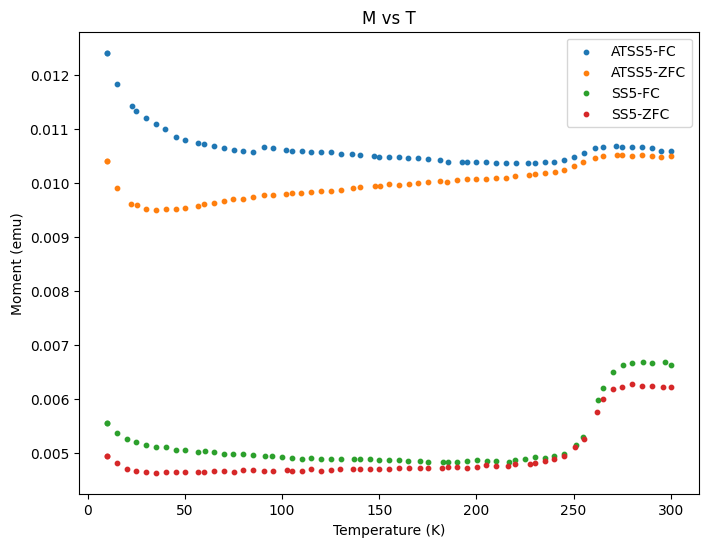

In [4]:

plt.figure(figsize=(8,6))

#  Iteration for each Sample-Run
for (sample, run), group in df_total.groupby(['Sample','Run']):
    plt.scatter(group['Temperature (K)'], group['Moment (emu/g)'], label=f'{sample}-{run}', s=10)
plt.xlabel("Temperature (K)")
plt.ylabel("Moment (emu)")
plt.title("M vs T")
plt.legend()
plt.show()

Based on the curves obtained, various conclusions can be drawn regarding the magnetic behavior of the system. In particular, the presence of an apparent magnetic transition in all samples around 260 K stands out, as do differences in the definition of this transition among them.

According to the literature on LaFeO₃, this type of transition is not typically observed, suggesting that its origin may be associated with specific characteristics of the samples studied, such as their synthesis method or possible effects of particle size and structural heterogeneity.

To investigate this phenomenon further, it is necessary to determine more precisely the temperature at which the transition occurs, as well as to quantify its width in each sample. This will allow for a more rigorous comparison of the observed differences and an evaluation of their possible physical origin.

To do this, we limited the graph to a region around the maximum peak of the derivative (dM/dT).

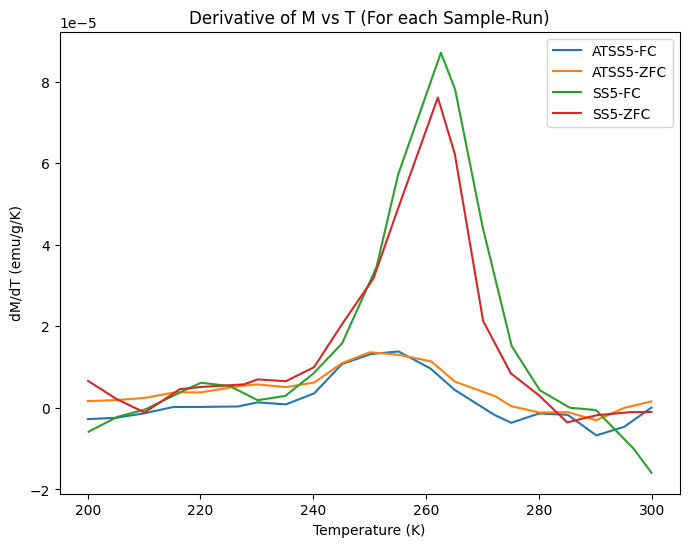

In [9]:
plt.figure(figsize=(8,6))

# Iteration for each Sample-Run
for (sample, run), group in df_total.groupby(['Sample','Run']):

    # Ordering the temperatures (to avoid conflicts)
    group_sorted = group.sort_values('Temperature (K)')

    # We only care to analyze the interval from 200 - 300 K
    mask = (group_sorted['Temperature (K)'] >= 200) & (group_sorted['Temperature (K)'] <= 300)
    temp = group_sorted['Temperature (K)'][mask]
    moment = group_sorted['Moment (emu/g)'][mask]
    
    # We calculate the gradient (dM/dT)
    dM_dT = np.gradient(moment, temp)
        
    # And we plot this gradient
    plt.plot(temp, dM_dT, label=f'{sample}-{run}')
    

plt.xlabel("Temperature (K)")
plt.ylabel("dM/dT (emu/g/K)")
plt.title("Derivative of M vs T (For each Sample-Run)")
plt.legend()
plt.show()

Although the difference in the definition of the transition is evident at first glance, the experimental curves are fitted using a Lorentzian profile in order to quantitatively determine the transition temperature and its associated width.

To simplify the analysis and avoid additional effects associated with the magnetic history, only measurements in ZFC (Zero-Field-Cooling) mode are considered. The fitting interval is defined as ±30 K around the maximum of the derivative dM/dT, where the transition is most pronounced.

The Lorentzian model used depends on two main parameters:  
- **μ (mu)**: corresponds to the position of the peak maximum and is associated with the magnetic transition temperature.  
- **σ (sigma)**: characterizes the peak width and is related to the transition broadening, which can be interpreted as an indirect measure of the system’s heterogeneity (e.g., particle size distribution or local variations in magnetic anisotropy).

The fitting results are presented both graphically and in tabular form, allowing for a direct comparison between the different samples.

| Sample   |   mu (K) |   sigma (K) |       R² |
|----------|----------|-------------|----------|
| ATSS5    |  251.936 |    12.8038  | 0.856759 |
| SS5      |  260.299 |     6.58674 | 0.953644 |


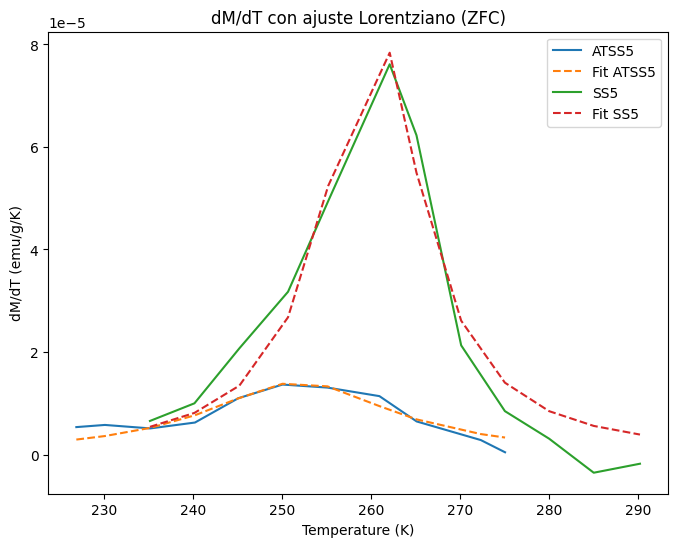

In [ ]:
plt.figure(figsize=(8,6))

df_zfc = df_total[df_total['Run'] == 'ZFC']  #We only care about the ZFC runs

results = []

for sample, group in df_zfc.groupby('Sample'):
    
    group_sorted = group.sort_values('Temperature (K)')
    
    mask = (group_sorted['Temperature (K)'] >= 200) & (group_sorted['Temperature (K)'] <= 300)
    temp = group_sorted['Temperature (K)'][mask].values  #Now we want to convert this into an array, so we place ".values"
    moment = group_sorted['Moment (emu/g)'][mask].values

    dM_dT = np.gradient(moment, temp)
    
    idx_max = np.argmax(dM_dT)
    
    x_fit = temp[(temp >= temp[idx_max]-30) & (temp <= temp[idx_max]+30)]
    y_fit = dM_dT[(temp >= temp[idx_max]-30) & (temp <= temp[idx_max]+30)]

    model = LorentzianModel(prefix=f'{sample}_')

    '''
    Below we are defining the initial parameters before the fit. This helps the model to converge
    faster, but these parameters are NOT fixed and will be recalculated during the least square method.
    '''
    params = model.make_params(
        amplitude=dM_dT[idx_max],
        center=temp[idx_max],
        sigma=5
    )

    try:
        result = model.fit(y_fit, params, x=x_fit)
        y_model = result.best_fit

        mu_fit = result.params[f'{sample}_center'].value
        sigma_fit = result.params[f'{sample}_sigma'].value
        R2 = result.rsquared

        results.append({
            'Sample': sample,
            'mu (K)': mu_fit,
            'sigma (K)': sigma_fit,
            'R²': R2
        })

    except Exception as e:
        print(f"Fit didn't converge for {sample}: {e}")  
        continue

    plt.plot(x_fit, y_fit, '-', label=f'{sample}')
    plt.plot(x_fit, y_model, '--', label=f'Fit {sample}')

df_params = pd.DataFrame(results)
print(tabulate(df_params, headers='keys', tablefmt='github', showindex=False))

plt.xlabel("Temperature (K)")
plt.ylabel("dM/dT (emu/g/K)")
plt.title("dM/dT con ajuste Lorentziano (ZFC)")
plt.legend()
plt.show()

In the case of sample SS5, the Lorentzian fit adequately describes the behavior of the curve (R² = 0.954), whereas for ATSS5 the fit is less accurate (R² = 0.857). However, this difference in the quality of the fit does not invalidate the interpretation of the extracted parameters; rather, it is consistent with the physical characteristics of each system.

First, the transition temperature obtained for SS5, in conjunction with the X-ray diffraction (XRD) results, which show the presence of a secondary hematite (Fe₂O₃) phase, coincides with the characteristic temperature of the **Morin transition** of hematite. It is well known that the position of this transition depends, among other factors, on particle size. In this regard, the shift observed in the transition temperature between SS5 and ATSS5 can be attributed to differences in the average size of the hematite grains present in each sample.

According to the histograms obtained via scanning electron microscopy (SEM), the grains in ATSS5 are smaller in size compared to those in SS5. This is consistent with the decrease in the Morin transition temperature observed in that sample.

Second, the difference in the width of the transition reinforces this interpretation. The ATSS5 sample exhibits a broader peak (larger σ), indicating a more temperature-distributed transition. This behavior is characteristic of systems with greater dispersion in particle size or in local magnetic anisotropy conditions. In contrast, SS5 exhibits a more defined transition, consistent with a more homogeneous size distribution.